## Cycle Leakage Test

Cycle leakage is where the cyclic features from other points of the output is admitted to a point of interest outside of those points. 

Cycle leakage is caused by:

- Improper implementation of the estimation algorithms (1)
- Windowing functions (2)
- Not appropraite parameter set (Odd Np, hop size is too large, etc.) (3)

We will again use FAM as an example. 

The test signal we are using is again the Rectangular BPSK with 0.05 Hz Carrier Frequency Offset, 0.1 Hz Symbol Rate, and sampling rate of 1 Hz. 

From the signal parameters, it can be deduced that the significant cycle frequency where the Spectral Correlation Density is not zero is:

- Non-Conjugate:
    - a = k * f_sym 

- Conjugate:
    - a = 2 * f_cfo + k * f_sym

where a is the significant cycle frequency, f_sym is the symbol rate and f_cfo is the carrier frequency offset.

Assuming (1) and (3) is checked using the validation test (We also provide a function to plot a cyclic domain plot to be extra careful). We only have (2) to test for. Looking at the cycle leakage might determine the quality of the algorithm as we want the significant cycle frequency to exhibit strong features not buried by other non-significant cycle frequencies.

In [7]:
from scf_test.algorithm import fam, ssca, scf_2d_fft_wrapper, Fast_SC
from algorithm.s3ca import s3ca
import scf_test.tests as test
import numpy as np
import matplotlib.pyplot as plt

Often cycle leakage is the most present where there is a strong sine wave energy, usually near the main lobe of the Power Spectral Density (Non conjugate alpha = 0 slice), so we will look at the area between -0.1 < a < 0.1 and a != 0. Reference: https://cyclostationary.blog/2016/03/22/csp-estimators-the-strip-spectral-correlation-analyzer/

SNR=-10 dB | mean: 0.989 | median: 0.991, mean: 9.894e-01, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 0.803 | median: 0.804, mean: 8.033e-01, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 0.652 | median: 0.652, mean: 6.522e-01, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 0.535 | median: 0.534, mean: 5.345e-01, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.439 | median: 0.440, mean: 4.387e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.365 | median: 0.364, mean: 3.647e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.305 | median: 0.305, mean: 3.051e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.256 | median: 0.255, mean: 2.557e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.219 | median: 0.219, mean: 2.186e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.187 | median: 0.187, mean: 1.874e-01, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.164 | median: 0.164, mean: 1.637e-01, outliers(>100): 0, nan: 0


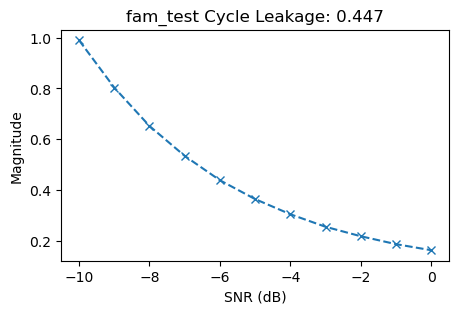

In [3]:
fam_result = test.window_test(fam, snr=np.arange(-10, 1), name="fam_test", fam=True, verbose=True)

SNR=-10 dB | mean: 0.887 | median: 0.885, mean: 8.867e-01, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 0.715 | median: 0.713, mean: 7.151e-01, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 0.581 | median: 0.581, mean: 5.814e-01, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 0.477 | median: 0.477, mean: 4.774e-01, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.394 | median: 0.393, mean: 3.937e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.325 | median: 0.324, mean: 3.249e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.272 | median: 0.273, mean: 2.723e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.228 | median: 0.228, mean: 2.285e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.193 | median: 0.194, mean: 1.934e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.166 | median: 0.166, mean: 1.662e-01, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.144 | median: 0.144, mean: 1.441e-01, outliers(>100): 0, nan: 0


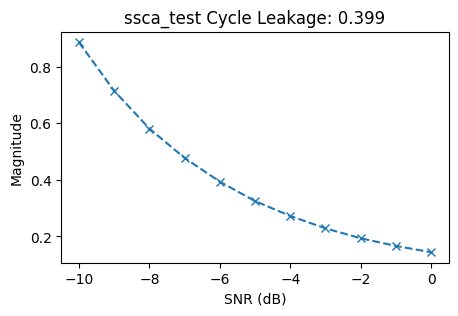

In [5]:
ssca_result = test.window_test(ssca, snr=np.arange(-10, 1), name="ssca_test", fam=False, verbose=True)

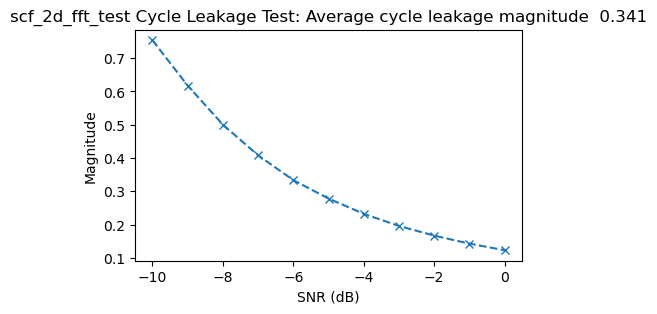

In [ ]:
# verbose=False to disable run statistics
scf_2d_fft_result = test.window_test(scf_2d_fft_wrapper, snr=np.arange(-10, 1), name="scf_2d_fft_test", fam=False, verbose=False)

## 2. Extended Cyclic Leakage Test

Of course, we can extend this test for different types of window. The windows being tested here are from scipy.signal libraries. However, this test requires the window being easily changed using a parameter. 

```
your_func(signal, window_1, window_2, ...)
```

The test also assumes window_1 has the size of Np and window_2 has the size of N (fam=False) or N/L (fam=True)

An example is provided below.

In [6]:
import pyfftw
import scipy.signal
from scf_test.visualization.psd import psd

In [9]:
def fam_window(signal, window_1="hamming", window_2="hamming", Np=64, L=16, conjugate=False, plot=False, coherence=False, fs=1):
    # L check
    if L < 1:
        L = 1
    
    # Pad signal (ensure that it is even -> fast fft)
    N = len(signal)
    if N % 2 == 1:
        N = N + 1
        signal = np.pad(signal, (0, 1))

    if Np % 2 == 1:
        Np = Np + 1

    # Pad signal more due to hopping
    P = int(np.floor(N / L))

    pad_length = int(Np - (N - P * L))

    pad_length = int(pad_length/2)
    
    signal_padded = np.pad(signal, (pad_length, pad_length))

    # Normalize energy and power on window to get correct PSD magnitude
    window_1 = scipy.signal.get_window(window_1, Np)
    window_2 = scipy.signal.get_window(window_2, P)

    window_1 = window_1.reshape((-1, 1))

    window_1 = window_1/ np.sqrt(np.sum(window_1**2))
    
    window_2 = window_2 / np.sum(window_2)

    N = len(signal_padded)

    L = int(L)

    Xt = pyfftw.empty_aligned((Np, P), dtype='complex')

    # Channelize signal with hop (Put segments in rows)
    for i in range(Np):
        Xt[i, :] = signal_padded[i:i + P*L:L]

    # Apply windowing function
    Xt = Xt * window_1

    Xt_conj = np.conj(Xt)

    # Enable cache for pyfftw (faster fft)
    pyfftw.interfaces.cache.enable()

    # FFT + Phase compensation
    Xt = np.fft.fftshift(pyfftw.interfaces.numpy_fft.fft(Xt, axis=0), axes=0)

    fk = np.fft.fftshift(np.fft.fftfreq(Np))

    i = np.arange(P)

    phase_compensation = np.exp(-1j*2*np.pi*fk.reshape((-1,1))*i*L)

    # Forming Yt*
    if conjugate:
        Yt_conj = np.fft.fftshift(pyfftw.interfaces.numpy_fft.fft(Xt_conj, axis=0), axes=0)
        Yt_conj = np.conj(Yt_conj * phase_compensation)
        Xt = Xt * phase_compensation 
    else:
        Xt = Xt * phase_compensation 
        Yt_conj = np.conj(Xt)

    # Frequency and alpha mapping calculation
    # alpha_i = fk - fl
    # alpha = alpha_i + q * delta_alpha = alpha_i + q/N
    # fj = (fk + fl)/2 = (k + l)/(2*L)
    
    fl = np.tile(fk.reshape((-1,1)), P)

    # Retain q in this range to minimize variability near top and bottom of channel pair region
    q_lim = int(P*L/(2*Np))

    q_size = q_lim*2

    q = np.arange(q_size) - q_lim
    delta_alpha = q/N

    fam = pyfftw.empty_aligned((Np * Np, q_size), dtype='float')
    fj = np.zeros((Np * Np, q_size), dtype='float')
    alpha = np.zeros((Np * Np, q_size), dtype='float')

    l = np.tile(np.arange(Np).reshape((-1, 1)), q_size) 

    # Multiply rows of Xt to Yt* and window + fft
    for k in range(Np):
        fj[k*Np:(k+1)*Np, :] = (k + l - Np)/(2*Np) 
        fam[k*Np:(k+1)*Np, :] = np.abs(pyfftw.interfaces.numpy_fft.fft(Xt[k, :] * Yt_conj * window_2, axis=1))[:, q]
        alpha[k*Np:(k+1)*Np, :] = (k - l)/Np + delta_alpha 

    # Remove any value outside the principal diamond
    mask = np.abs(fj) + np.abs(alpha/2) > 0.5

    fam[mask] = 0

    fam = fam.reshape((Np, Np*q_size))
    fj = fj.reshape((Np, Np*q_size))
    alpha = alpha.reshape((Np, Np*q_size))
    
    # Optional spectral coherence calculation from SSCA SCF
    if coherence:
        N = Np
        
        sample_1 = np.rint((fj + alpha/2) * N/fs).astype(int)
        if conjugate:
            sample_2 = np.rint((alpha/2 - fj) * N/fs).astype(int)
        else:
            sample_2 = np.rint((fj - alpha/2) * N/fs).astype(int)

        psd_fsm = np.fft.ifftshift(psd(signal, L=Np, method="bartlett", db=False, plot=False))

        coherence_denominator = np.sqrt(psd_fsm[sample_1] * psd_fsm[sample_2])

        fam_coh = fam/coherence_denominator

    if plot:
        plt.figure(figsize=(6, 6))
        plt.pcolormesh(fj, alpha, fam)

        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Cycle Frequency (Hz)")
        if conjugate:
            plt.title("Conj FAM")
        else:
            plt.title("FAM")

    if coherence:
        return fam_coh, fj, alpha 
    else:
        return fam, fj, alpha 

Best Windows: a(n): flattop, g(n): boxcar with 0.0966841921505848 average cycle leakage magnitudes.


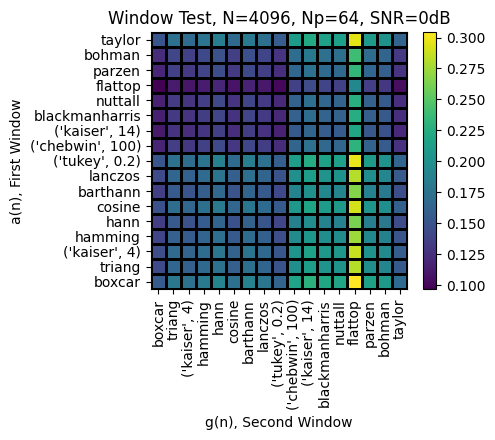

In [10]:
fam_result_extended = test.extended_window_test(fam_window, name="fam", fam=True, plot=True)

In [4]:
def scf_2d_fft_wrapper(signal, Np=64, fs=1, conjugate=False, coherence=False, window_1="boxcar", window_2=None):
    Sx, f, alpha = scf_2d_fft(signal, max_lag=Np, fs=fs, conjugate=conjugate, window=window_1)

    N = len(signal)
    
     # Optional spectral coherence calculation from SSCA SCF
    if coherence:
        sample_1 = np.rint((f + alpha/2) * Np/fs).astype(int)
        if conjugate:
            sample_2 = np.rint((alpha/2 - f) * Np/fs).astype(int)
        else:
            sample_2 = np.rint((f - alpha/2) * Np/fs).astype(int)

        psd_tsm = np.fft.ifftshift(psd(signal, L=Np, method="welch", db=False, plot=False))

        coherence_denominator = np.sqrt(psd_tsm[sample_1] * psd_tsm[sample_2])

        # mask = np.abs(alpha) < fs/(2*N)

        # psd = np.fft.ifftshift(Sx[mask])

        # coherence_denominator = np.sqrt(psd[sample_1] * psd[sample_2])

        Sx = Sx/coherence_denominator

    return np.abs(Sx), f, alpha

Best Windows: a(n): flattop, g(n): boxcar with 0.078351126336621 average cycle leakage magnitudes.


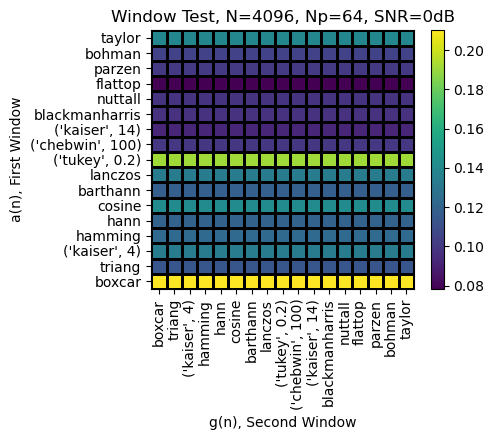

In [5]:
scf_2d_fft_result_extended = test.extended_window_test(scf_2d_fft_wrapper, name="scf_2d_fft", fam=False, plot=True)

SNR=-10 dB | mean: 0.333 | median: 0.334, mean: 3.331e-01, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 0.270 | median: 0.270, mean: 2.700e-01, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 0.218 | median: 0.219, mean: 2.180e-01, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 0.179 | median: 0.178, mean: 1.785e-01, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.146 | median: 0.146, mean: 1.456e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.120 | median: 0.120, mean: 1.203e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.100 | median: 0.100, mean: 9.966e-02, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.083 | median: 0.083, mean: 8.296e-02, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.069 | median: 0.069, mean: 6.926e-02, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.058 | median: 0.058, mean: 5.794e-02, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.049 | median: 0.049, mean: 4.948e-02, outliers(>100): 0, nan: 0


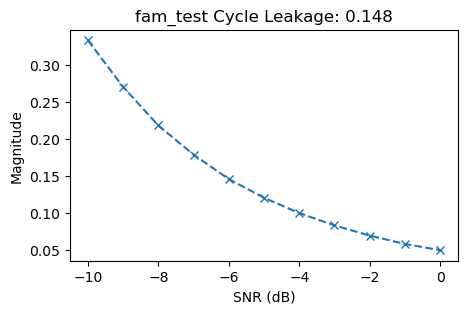

SNR=-10 dB | mean: 0.481 | median: 0.481, mean: 4.808e-01, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 0.391 | median: 0.390, mean: 3.905e-01, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 0.316 | median: 0.316, mean: 3.161e-01, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 0.257 | median: 0.258, mean: 2.573e-01, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.212 | median: 0.212, mean: 2.118e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.175 | median: 0.174, mean: 1.745e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.144 | median: 0.144, mean: 1.445e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.120 | median: 0.120, mean: 1.203e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.102 | median: 0.101, mean: 1.015e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.086 | median: 0.086, mean: 8.589e-02, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.073 | median: 0.073, mean: 7.340e-02, outliers(>100): 0, nan: 0


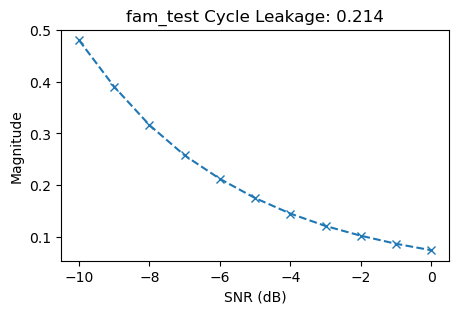

SNR=-10 dB | mean: 0.693 | median: 0.693, mean: 6.932e-01, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 0.562 | median: 0.562, mean: 5.620e-01, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 0.458 | median: 0.459, mean: 4.577e-01, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 0.373 | median: 0.373, mean: 3.735e-01, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.307 | median: 0.306, mean: 3.073e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.255 | median: 0.255, mean: 2.551e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.211 | median: 0.210, mean: 2.105e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.178 | median: 0.177, mean: 1.776e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.150 | median: 0.150, mean: 1.499e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.128 | median: 0.128, mean: 1.278e-01, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.110 | median: 0.110, mean: 1.100e-01, outliers(>100): 0, nan: 0


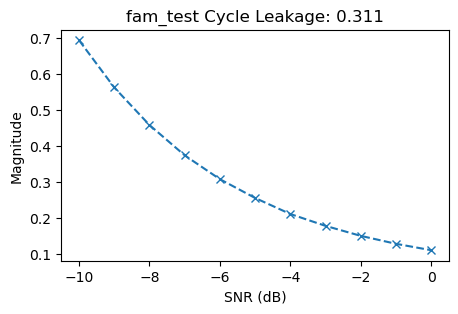

SNR=-10 dB | mean: 0.989 | median: 0.987, mean: 9.893e-01, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 0.802 | median: 0.802, mean: 8.023e-01, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 0.656 | median: 0.656, mean: 6.558e-01, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 0.533 | median: 0.534, mean: 5.331e-01, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.441 | median: 0.441, mean: 4.414e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.364 | median: 0.364, mean: 3.640e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.305 | median: 0.305, mean: 3.051e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.257 | median: 0.257, mean: 2.569e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.219 | median: 0.219, mean: 2.189e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.188 | median: 0.187, mean: 1.877e-01, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.164 | median: 0.164, mean: 1.639e-01, outliers(>100): 0, nan: 0


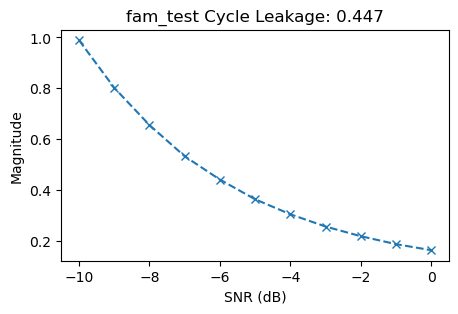

SNR=-10 dB | mean: 1.398 | median: 1.398, mean: 1.398e+00, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 1.138 | median: 1.138, mean: 1.138e+00, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 0.924 | median: 0.924, mean: 9.243e-01, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 0.761 | median: 0.761, mean: 7.610e-01, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.626 | median: 0.626, mean: 6.262e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.521 | median: 0.521, mean: 5.207e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.436 | median: 0.436, mean: 4.358e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.367 | median: 0.367, mean: 3.674e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.314 | median: 0.314, mean: 3.143e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.270 | median: 0.270, mean: 2.704e-01, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.236 | median: 0.236, mean: 2.362e-01, outliers(>100): 0, nan: 0


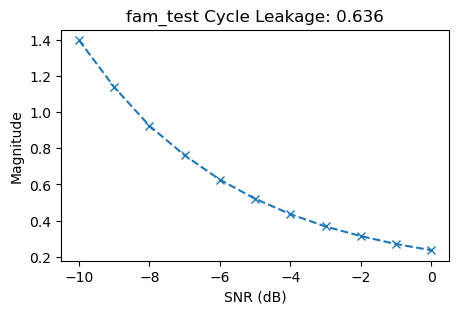

SNR=-10 dB | mean: 1.980 | median: 1.977, mean: 1.980e+00, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 1.607 | median: 1.608, mean: 1.607e+00, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 1.311 | median: 1.310, mean: 1.311e+00, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 1.073 | median: 1.072, mean: 1.073e+00, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 0.889 | median: 0.888, mean: 8.889e-01, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 0.738 | median: 0.739, mean: 7.378e-01, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.619 | median: 0.619, mean: 6.191e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.524 | median: 0.526, mean: 5.238e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.445 | median: 0.445, mean: 4.454e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.386 | median: 0.386, mean: 3.864e-01, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.337 | median: 0.337, mean: 3.374e-01, outliers(>100): 0, nan: 0


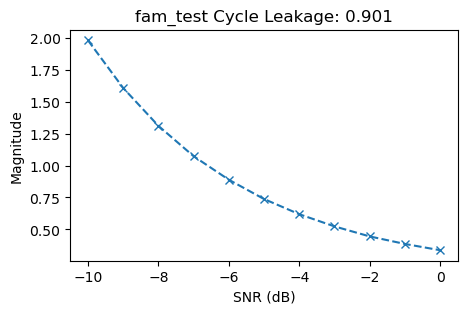

SNR=-10 dB | mean: 2.790 | median: 2.793, mean: 2.790e+00, outliers(>100): 0, nan: 0
SNR=-9 dB | mean: 2.260 | median: 2.258, mean: 2.260e+00, outliers(>100): 0, nan: 0
SNR=-8 dB | mean: 1.836 | median: 1.835, mean: 1.836e+00, outliers(>100): 0, nan: 0
SNR=-7 dB | mean: 1.516 | median: 1.513, mean: 1.516e+00, outliers(>100): 0, nan: 0
SNR=-6 dB | mean: 1.250 | median: 1.251, mean: 1.250e+00, outliers(>100): 0, nan: 0
SNR=-5 dB | mean: 1.038 | median: 1.038, mean: 1.038e+00, outliers(>100): 0, nan: 0
SNR=-4 dB | mean: 0.869 | median: 0.868, mean: 8.687e-01, outliers(>100): 0, nan: 0
SNR=-3 dB | mean: 0.738 | median: 0.737, mean: 7.376e-01, outliers(>100): 0, nan: 0
SNR=-2 dB | mean: 0.632 | median: 0.633, mean: 6.317e-01, outliers(>100): 0, nan: 0
SNR=-1 dB | mean: 0.547 | median: 0.547, mean: 5.468e-01, outliers(>100): 0, nan: 0
SNR=0 dB | mean: 0.478 | median: 0.478, mean: 4.779e-01, outliers(>100): 0, nan: 0


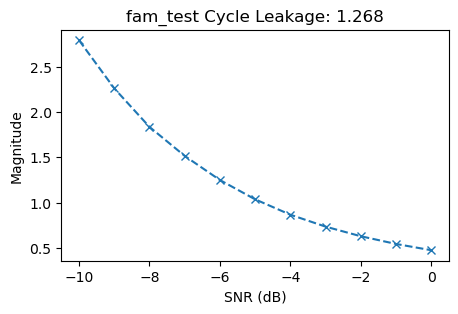

In [8]:
Np = [8, 16, 32, 64, 128, 256, 512]

for n_channels in Np:
    fam_result = test.window_test(fam, snr=np.arange(-10, 1), Np=n_channels, L=n_channels/4, name="fam_test", fam=True, verbose=True)